# Week 7: Line Plot of IoT Sensor Readings Over Time

This notebook visualizes IoT logistics sensor readings over time. The analysis focuses on package temperature, humidity, inventory level, and asset utilization trends, with selected views grouped by standardized package status.

## 1. Import Required Libraries

The required libraries are loaded for data handling, timestamp processing, and visualization.

In [1]:
# Import required libraries
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid", context="notebook")

# Configure pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load the Dataset

The dataset is loaded using a repo-friendly path. This allows the notebook to run when the repository is cloned, provided that the CSV file remains inside the `IOT Data Simulation` folder.

In [2]:
# Define possible dataset locations
possible_paths = [
    Path("IOT Data Simulation") / "smart_logistic_tracker_japan.csv",
    Path("../IOT Data Simulation") / "smart_logistic_tracker_japan.csv",
    Path("smart_logistic_tracker_japan.csv"),
    Path("/mnt/data/smart_logistic_tracker_japan.csv")
]

# Select the first available path
file_path = next((path for path in possible_paths if path.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        "Dataset file was not found. Expected file name: smart_logistic_tracker_japan.csv. "
        "Recommended repository location: IOT Data Simulation/smart_logistic_tracker_japan.csv"
    )

# Load the dataset
df = pd.read_csv(file_path)

# Display the selected file path and preview the dataset
print("Loaded dataset from:", file_path)
df.head()

Loaded dataset from: IOT Data Simulation/smart_logistic_tracker_japan.csv


,timestamp,carrier,tracking_number,package_id,origin,current_location,delivery_location,prefecture,latitude,longitude,latest_status,logistics_delay_reason,logistics_delay,order_date,expected_delivery_date,waiting_time_minutes,perishable,temperature,humidity,rfid_tag,rfid_verified,tamper_alert,traffic_status,inventory_level,asset_utilization
0,2026-05-04 13:50:26.857905,Yamato Transport,942646961460,PKG7545,Tokyo,Naha Central Post Office,Tokyo,Kanagawa,35.993159,139.038781,Out for Delivery,NaN,0,2026-04-29 23:26:26.858009,2026-05-05 23:26:26.858015,45,No,10.7,40,RFID736892,False,No,Heavy,99,84.59
1,2026-05-03 23:36:26.858095,Japan Post,74355111775,PKG2659,Tokyo,Nagoya Central Post Office,Kyoto,Kanagawa,35.691292,139.130870,Arrival,NaN,0,2026-04-28 23:26:26.858141,2026-05-07 23:26:26.858146,54,Yes,6.2,82,RFID156229,False,Yes,Detour,363,53.39
2,2026-05-04 08:32:26.858217,Japan Post,217497030475,PKG7965,Osaka,Nagoya Central Post Office,Osaka,Aichi,35.591109,139.784940,Storage,NaN,1,2026-05-03 23:26:26.858267,2026-05-08 23:26:26.858271,144,Yes,-3.1,86,RFID890703,True,Yes,Heavy,25,95.75
3,2026-05-04 02:35:26.858332,Japan Post,249781996688,PKG5296,Fukuoka,Sapporo Central Post Office,Sapporo,Osaka,35.570440,139.689163,Delivered to the delivery address,NaN,0,2026-05-03 23:26:26.858370,2026-05-05 23:26:26.858374,173,Yes,6.3,87,RFID603182,True,Yes,Detour,145,63.84
4,2026-05-04 08:28:26.858444,Japan Post,718415724062,PKG9987,Fukuoka,Yokohama Sales Office,Sapporo,Hokkaido,35.679375,139.408071,Bring it back due to your absence,Address Unknown,1,2026-05-03 23:26:26.858492,2026-05-07 23:26:26.858501,82,No,0.7,60,RFID921432,False,Yes,Detour,34,56.28


## 3. Check the Dataset Structure

The dataset shape, column names, and data types are reviewed before visualization to confirm that the required fields are available.

In [3]:
# Display dataset size and column information
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (100, 25)

Column names:
['timestamp', 'carrier', 'tracking_number', 'package_id', 'origin', 'current_location', 'delivery_location', 'prefecture', 'latitude', 'longitude', 'latest_status', 'logistics_delay_reason', 'logistics_delay', 'order_date', 'expected_delivery_date', 'waiting_time_minutes', 'perishable', 'temperature', 'humidity', 'rfid_tag', 'rfid_verified', 'tamper_alert', 'traffic_status', 'inventory_level', 'asset_utilization']

Data types:
timestamp                  object
carrier                    object
tracking_number             int64
package_id                 object
origin                     object
current_location           object
delivery_location          object
prefecture                 object
latitude                  float64
longitude                 float64
latest_status              object
logistics_delay_reason     object
logistics_delay             int64
order_date                 object
expected_delivery_date     object
waiting_time_minute

## 4. Prepare Timestamp and Package Status Fields

The timestamp field is converted into datetime format. The package status values are also standardized into a consistent set of logistics categories: `To Ship`, `In Transit`, `Delivered`, `Delayed`, and `Cancelled`.

In [4]:
# Convert timestamp column to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Remove records with invalid timestamps, then sort records chronologically
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Define a function for standardizing package status labels
def standardize_package_status(status):
    status_text = str(status).strip().lower()

    if "delivered" in status_text:
        return "Delivered"
    if "returned" in status_text:
        return "Cancelled"
    if (
        "delay" in status_text
        or "under investigation" in status_text
        or "absence" in status_text
        or "unknown" in status_text
        or "failure" in status_text
    ):
        return "Delayed"
    if (
        "storage" in status_text
        or "hold" in status_text
    ):
        return "To Ship"

    return "In Transit"

# Create standardized package status column
df["package_status"] = df["latest_status"].apply(standardize_package_status)

# Set package status order for consistent plotting
status_order = ["To Ship", "In Transit", "Delivered", "Delayed", "Cancelled"]
df["package_status"] = pd.Categorical(df["package_status"], categories=status_order, ordered=True)

# Review standardized package status distribution
df["package_status"].value_counts().reindex(status_order)

package_status
To Ship       15
In Transit    34
Delivered      9
Delayed       24
Cancelled     18
Name: count, dtype: int64

## 5. Prepare Sensor Fields for Visualization

The relevant numeric sensor fields are selected and renamed for clearer visualization labels. Hourly aggregation is applied to reduce visual clutter while preserving the overall time-based trend.

In [5]:
# Define sensor columns used in the activity
sensor_columns = ["temperature", "humidity", "inventory_level", "asset_utilization"]

# Define readable sensor labels
sensor_labels = {
    "temperature": "Temperature",
    "humidity": "Humidity",
    "inventory_level": "Inventory Level",
    "asset_utilization": "Asset Utilization"
}

# Define consistent colors for sensor-based visualizations
sensor_colors = {
    "Temperature": "#4C72B0",
    "Humidity": "#DD8452",
    "Inventory Level": "#55A868",
    "Asset Utilization": "#C44E52"
}

# Define consistent colors for package status visualizations
status_colors = {
    "To Ship": "#8172B3",
    "In Transit": "#4C72B0",
    "Delivered": "#55A868",
    "Delayed": "#DD8452",
    "Cancelled": "#C44E52"
}

# Convert sensor columns to numeric values
for col in sensor_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create hourly timestamp for aggregation
df["timestamp_hour"] = df["timestamp"].dt.floor("h")

# Aggregate sensor readings by hour
hourly_df = (
    df.groupby("timestamp_hour", as_index=False)[sensor_columns]
    .mean()
    .rename(columns={"timestamp_hour": "timestamp"})
)

# Aggregate sensor readings by hour and package status
status_hourly_df = (
    df.groupby(["timestamp_hour", "package_status"], as_index=False, observed=False)[sensor_columns]
    .mean()
    .rename(columns={"timestamp_hour": "timestamp"})
)

# Convert hourly data into long format for combined sensor plotting
hourly_long = hourly_df.melt(
    id_vars="timestamp",
    value_vars=sensor_columns,
    var_name="sensor_type",
    value_name="sensor_value"
)

# Apply readable sensor names
hourly_long["sensor_type"] = hourly_long["sensor_type"].replace(sensor_labels)

# Set the order of sensor categories in the legend
sensor_order = list(sensor_colors.keys())

# Preview prepared hourly data
hourly_df.head()

,timestamp,temperature,humidity,inventory_level,asset_utilization
0,2026-05-03 23:00:00,8.528571,67.142857,186.571429,75.847143
1,2026-05-04 00:00:00,7.200000,71.500000,247.000000,89.910000
2,2026-05-04 01:00:00,5.240000,72.000000,325.200000,73.696000
3,2026-05-04 02:00:00,5.080000,65.000000,274.000000,72.196000
4,2026-05-04 04:00:00,8.780000,63.400000,139.800000,70.786000


### Important Note: The original `latest_status` values contain detailed courier-style updates. For clearer visualization, these values are grouped into five standardized logistics categories: To Ship, In Transit, Delivered, Delayed, and Cancelled. This grouping is used only for visualization and does not modify the original CSV data.

## 6. IoT Package Temperature Over Time by Status

This visualization shows how package temperature changes over time across standardized package statuses. This is useful for logistics monitoring, especially for perishable items that may require temperature control.

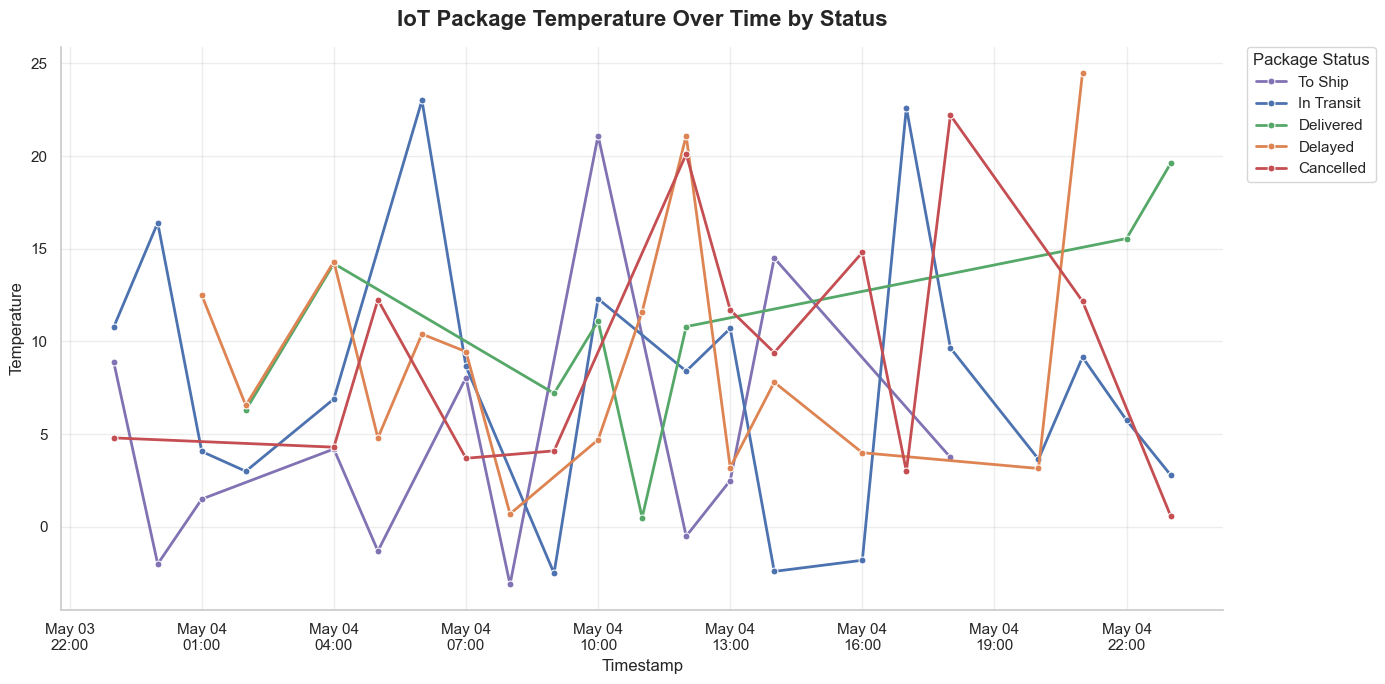

In [6]:
# Create package temperature line plot by status
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=status_hourly_df,
    x="timestamp",
    y="temperature",
    hue="package_status",
    hue_order=status_order,
    palette=status_colors,
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Package Temperature Over Time by Status", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Temperature", fontsize=12)

# Format x-axis labels using fixed time intervals
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Package Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 7. IoT Package Humidity Over Time by Status

This visualization shows humidity trends over time across standardized package statuses. Humidity monitoring supports quality control for packages that may be sensitive to moisture.

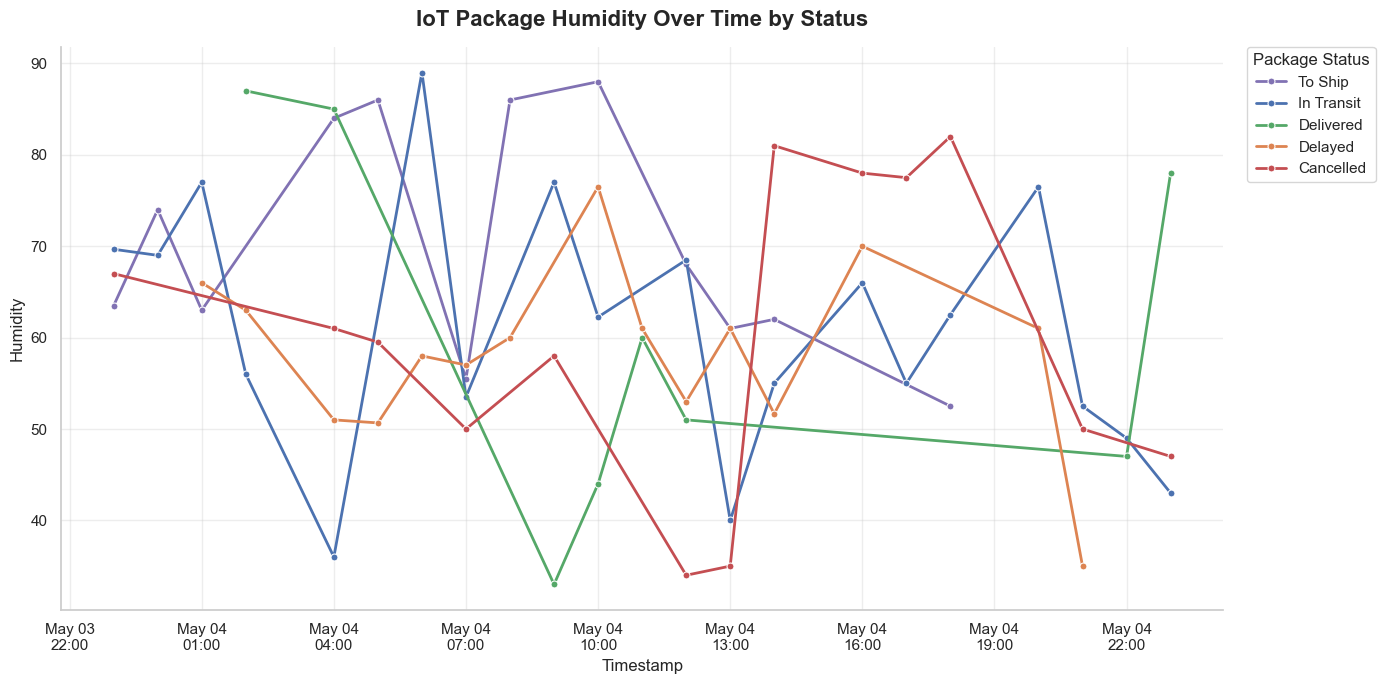

In [7]:
# Create package humidity line plot by status
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=status_hourly_df,
    x="timestamp",
    y="humidity",
    hue="package_status",
    hue_order=status_order,
    palette=status_colors,
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Package Humidity Over Time by Status", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Humidity", fontsize=12)

# Format x-axis labels using fixed time intervals
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Package Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 8. Inventory Level Over Time by Status

This visualization compares inventory level trends across standardized package statuses.

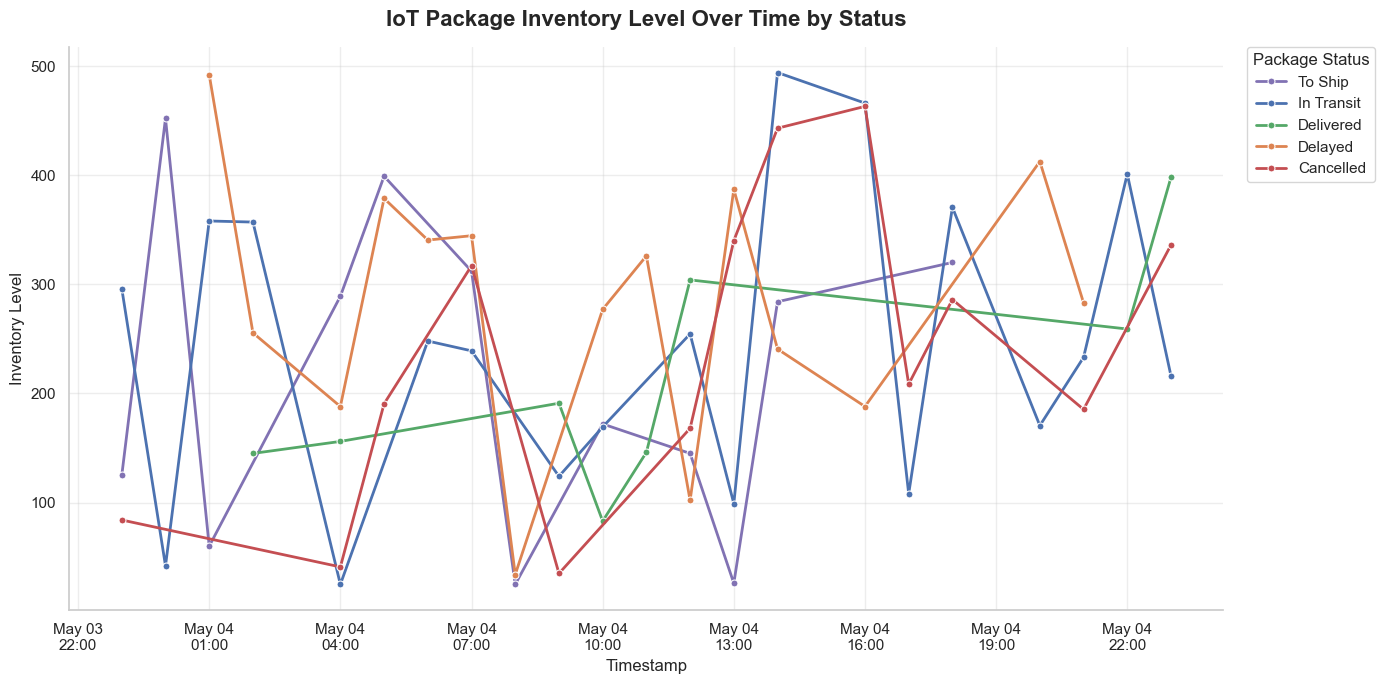

In [8]:
# Create inventory level line plot by status
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=status_hourly_df,
    x="timestamp",
    y="inventory_level",
    hue="package_status",
    hue_order=status_order,
    palette=status_colors,
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Package Inventory Level Over Time by Status", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Inventory Level", fontsize=12)

# Format x-axis labels using fixed time intervals
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Package Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 9. Asset Utilization Over Time by Status

This visualization compares asset utilization trends across standardized package statuses.

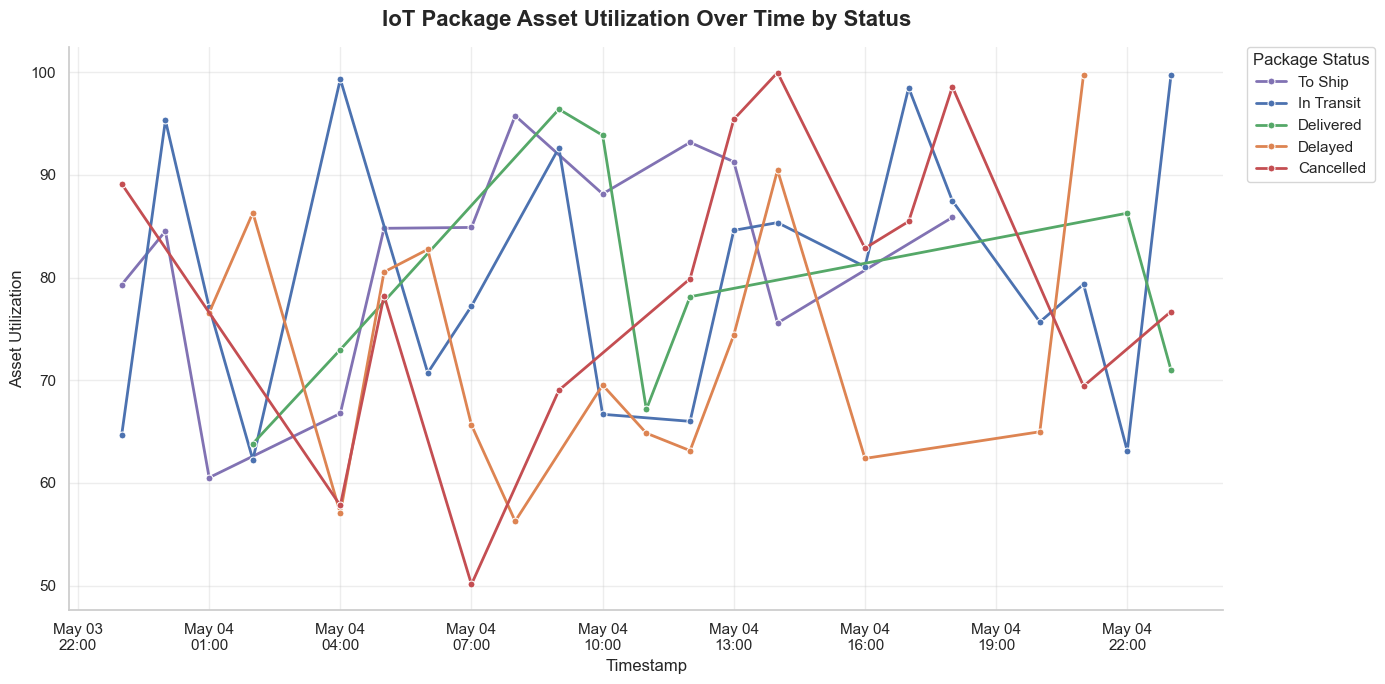

In [9]:
# Create asset utilization line plot by status
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=status_hourly_df,
    x="timestamp",
    y="asset_utilization",
    hue="package_status",
    hue_order=status_order,
    palette=status_colors,
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Package Asset Utilization Over Time by Status", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Asset Utilization", fontsize=12)

# Format x-axis labels using fixed time intervals
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Package Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 10. Combined IoT Sensor Readings Over Time

This visualization displays the selected IoT sensor readings in a single non-normalized line plot. Since the variables use different value ranges, the chart is used mainly for a broad comparison of movement over time.

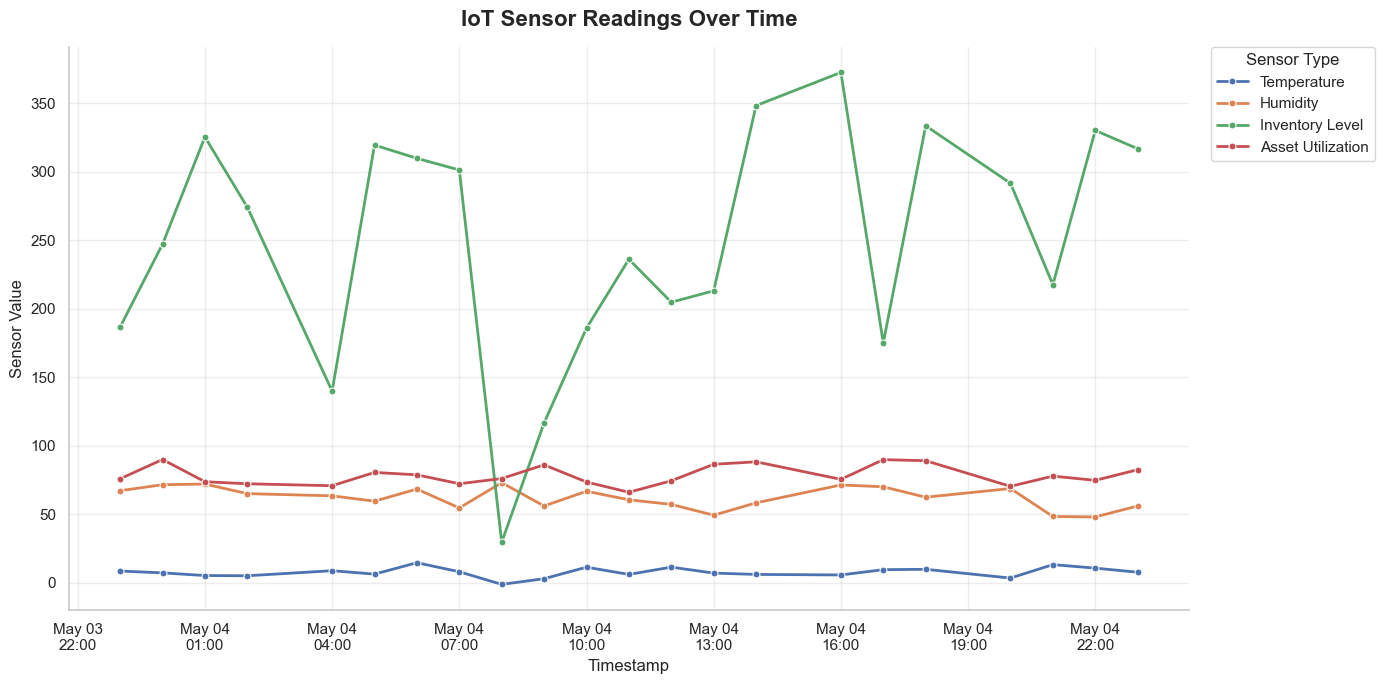

In [10]:
# Create the non-normalized multi-sensor line plot
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=hourly_long,
    x="timestamp",
    y="sensor_value",
    hue="sensor_type",
    hue_order=sensor_order,
    palette=sensor_colors,
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax
)

# Add chart title and axis labels
ax.set_title("IoT Sensor Readings Over Time", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Timestamp", fontsize=12)
ax.set_ylabel("Sensor Value", fontsize=12)

# Format x-axis labels using fixed time intervals
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

# Improve plot readability
ax.grid(True, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside the plotting area
ax.legend(
    title="Sensor Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

## 11. Separate Sensor Trend Visualizations

Separate line plots are created for each sensor reading to make individual trends easier to inspect. Each chart uses the same color assigned to that sensor in the combined visualization.

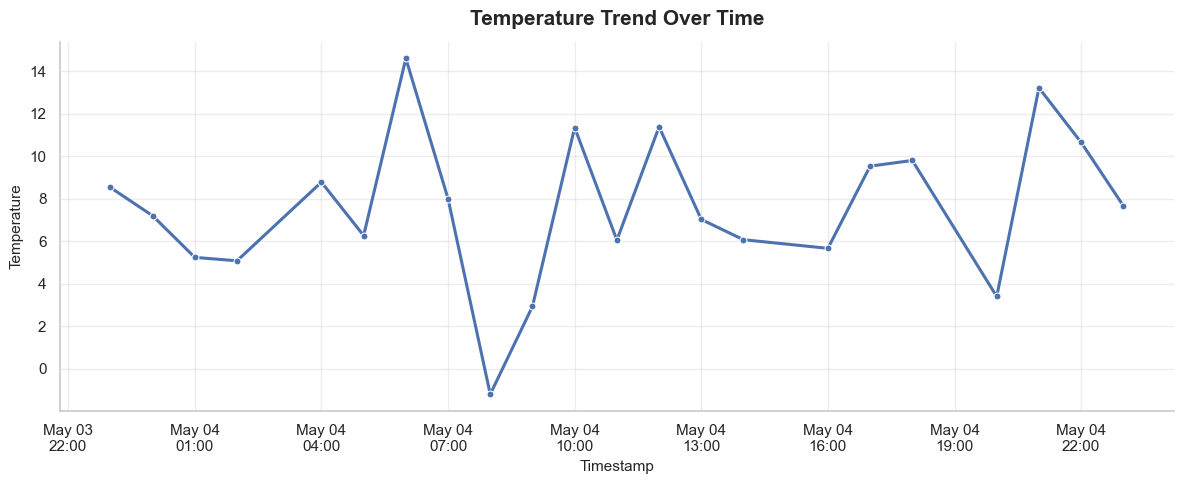

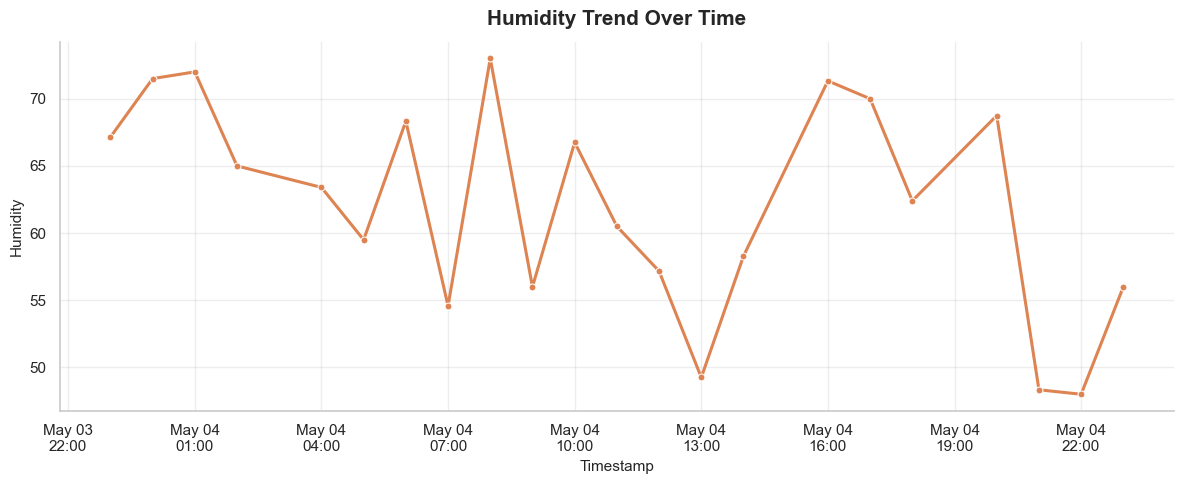

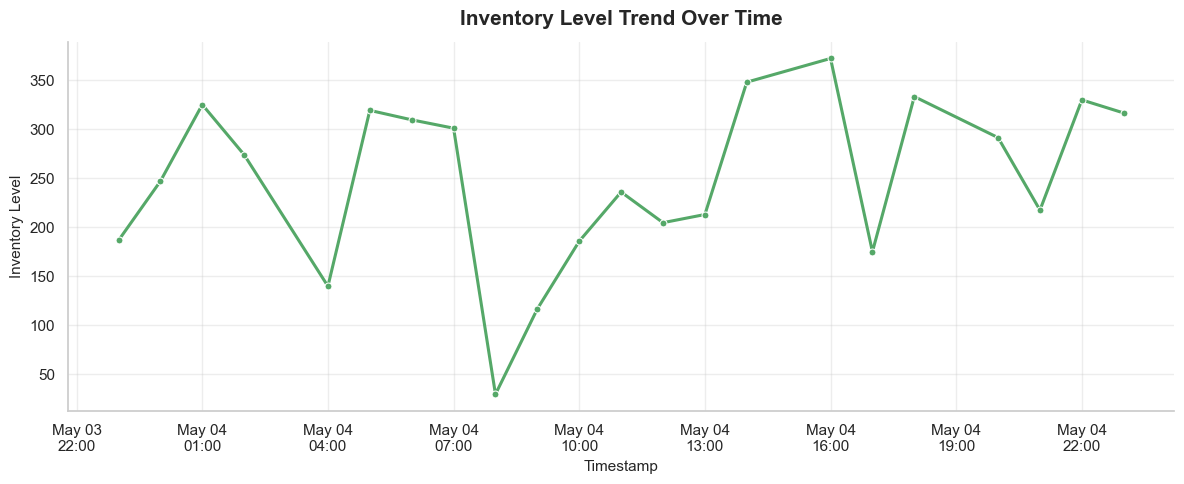

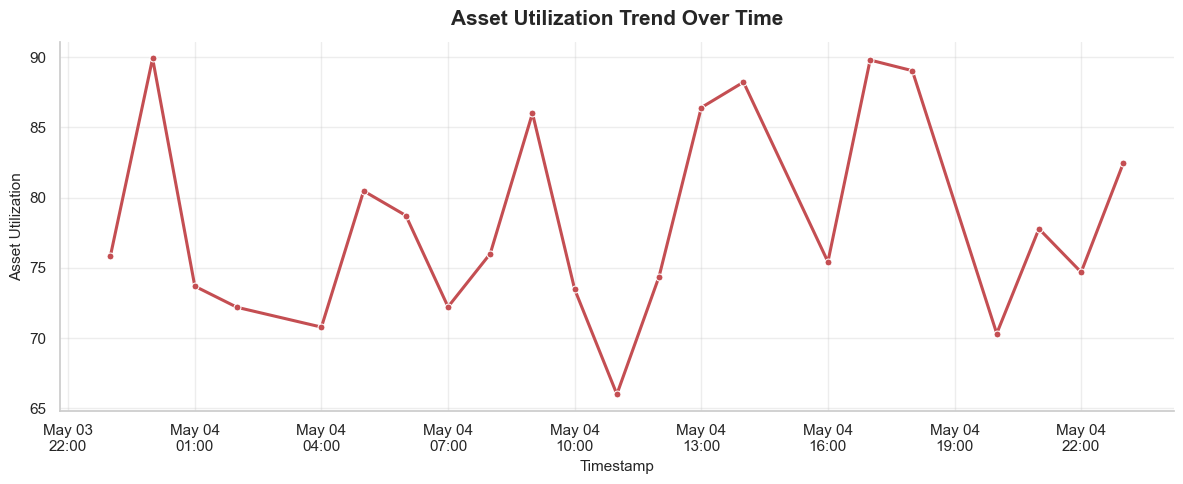

In [11]:
# Create one separate trend visualization per sensor reading
for col in sensor_columns:
    label = sensor_labels[col]
    color = sensor_colors[label]

    fig, ax = plt.subplots(figsize=(12, 5))

    sns.lineplot(
        data=hourly_df,
        x="timestamp",
        y=col,
        color=color,
        marker="o",
        markersize=5,
        linewidth=2.2,
        ax=ax
    )

    # Add chart title and axis labels
    ax.set_title(f"{label} Trend Over Time", fontsize=15, fontweight="bold", pad=12)
    ax.set_xlabel("Timestamp", fontsize=11)
    ax.set_ylabel(label, fontsize=11)

    # Format x-axis labels using fixed time intervals
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))

    # Improve plot readability
    ax.grid(True, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

## 12. Summary

The visualizations show time-based changes in IoT logistics sensor readings. Standardized package statuses make the plots easier to interpret, while hourly aggregation reduces visual clutter and supports clearer trend analysis.